In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('events.csv')

In [4]:
df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [5]:
df['end_datetime'].loc[df['event_type'] == 'planned'].head(50)

8           2024-02-12 14:05:46+00
40          2024-01-30 11:31:46+00
45          2024-01-30 21:20:46+00
52          2024-01-31 09:05:46+00
82          2024-03-08 10:05:46+00
139         2024-02-01 09:05:46+00
158         2024-01-31 18:26:46+00
166         2024-02-01 06:07:46+00
192         2024-03-08 04:32:46+00
229         2024-02-01 11:31:46+00
235         2024-02-02 09:05:46+00
241         2024-02-01 21:05:46+00
253         2024-02-01 22:12:46+00
312         2024-02-03 09:05:46+00
355         2024-03-09 01:18:46+00
375         2024-02-03 12:20:46+00
412         2024-03-09 02:25:46+00
426         2024-03-12 06:38:46+00
433         2024-02-04 09:05:46+00
437     2024-02-04 09:05:46.921+00
439         2024-02-04 14:05:46+00
468         2024-02-05 06:05:46+00
478         2024-02-05 04:41:46+00
490         2024-02-04 17:25:46+00
502         2024-02-05 18:05:46+00
553         2024-03-10 10:05:46+00
557         2024-03-09 21:35:46+00
575         2024-02-06 09:05:46+00
629         2024-02-

In [6]:
df.shape

(8173, 46)

In [7]:
df['event_cause'].loc[df['requires_road_closure_int'] == 1].head(20)

KeyError: 'requires_road_closure_int'

In [8]:
df[['resolved_by_id', 'closed_by_id']].tail()

,resolved_by_id,closed_by_id
8168,NaN,FKUSR01083
8169,NaN,FKUSR01486
8170,NaN,FKUSR01992
8171,NaN,NaN
8172,NaN,FKUSR01675


In [9]:
cols = df.columns.tolist()

In [10]:
df['road_closure_class'].head(20)

KeyError: 'road_closure_class'

In [11]:
df['log_duration_min'].notnull().sum()

KeyError: 'log_duration_min'

In [12]:

mask = (df['resolved_datetime'] != 'NULL') & df['resolved_datetime'].notnull()
df.loc[mask, 'resolved_datetime'].count()

np.int64(74)

In [13]:
pd.to_datetime(df['start_datetime']).dt.hour.head()

ValueError: time data "2024-02-12 02:05:46+00" doesn't match format "%Y-%m-%d %H:%M:%S.%f%z", at position 8. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
df['priority'].loc[df['event_type'] == 'planned'].head(20)

8      High
40     High
45      Low
52     High
82     High
139    High
158    High
166    High
192     Low
229    High
235    High
241    High
253     Low
312    High
355     Low
375    High
412    High
426     Low
433     Low
437     Low
Name: priority, dtype: object

In [1]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(x=missing.values, y=missing.index, color="steelblue")
plt.xlabel("% missing")
plt.ylabel("Columns")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [15]:
print("Columns >90% missing:\n", missing[missing > 90])

Columns >90% missing:
 meta_data                100.000000
map_file                 100.000000
comment                  100.000000
direction                 99.473877
resolved_at_address       99.094580
resolved_at_latitude      99.094580
resolved_by_id            99.094580
resolved_datetime         99.094580
resolved_at_longitude     99.094580
citizen_accident_id       98.433868
assigned_to_police_id     98.433868
route_path                98.323749
cargo_material            96.623027
reason_breakdown          96.623027
age_of_truck              96.623027
end_datetime              94.004649
end_address               91.594274
dtype: float64


In [16]:
for col in ["start_datetime", "end_datetime", "created_date", "modified_datetime",
          "closed_datetime", "resolved_datetime"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

df["hour"] = df["start_datetime"].dt.hour
df["dayofweek"] = df["start_datetime"].dt.day_name()
df["month"] = df["start_datetime"].dt.tz_localize(None).dt.to_period("M").astype(str)
df["date"] = df["start_datetime"].dt.date

df["resolution_min"] = (df["closed_datetime"] - df["start_datetime"]).dt.total_seconds() / 60

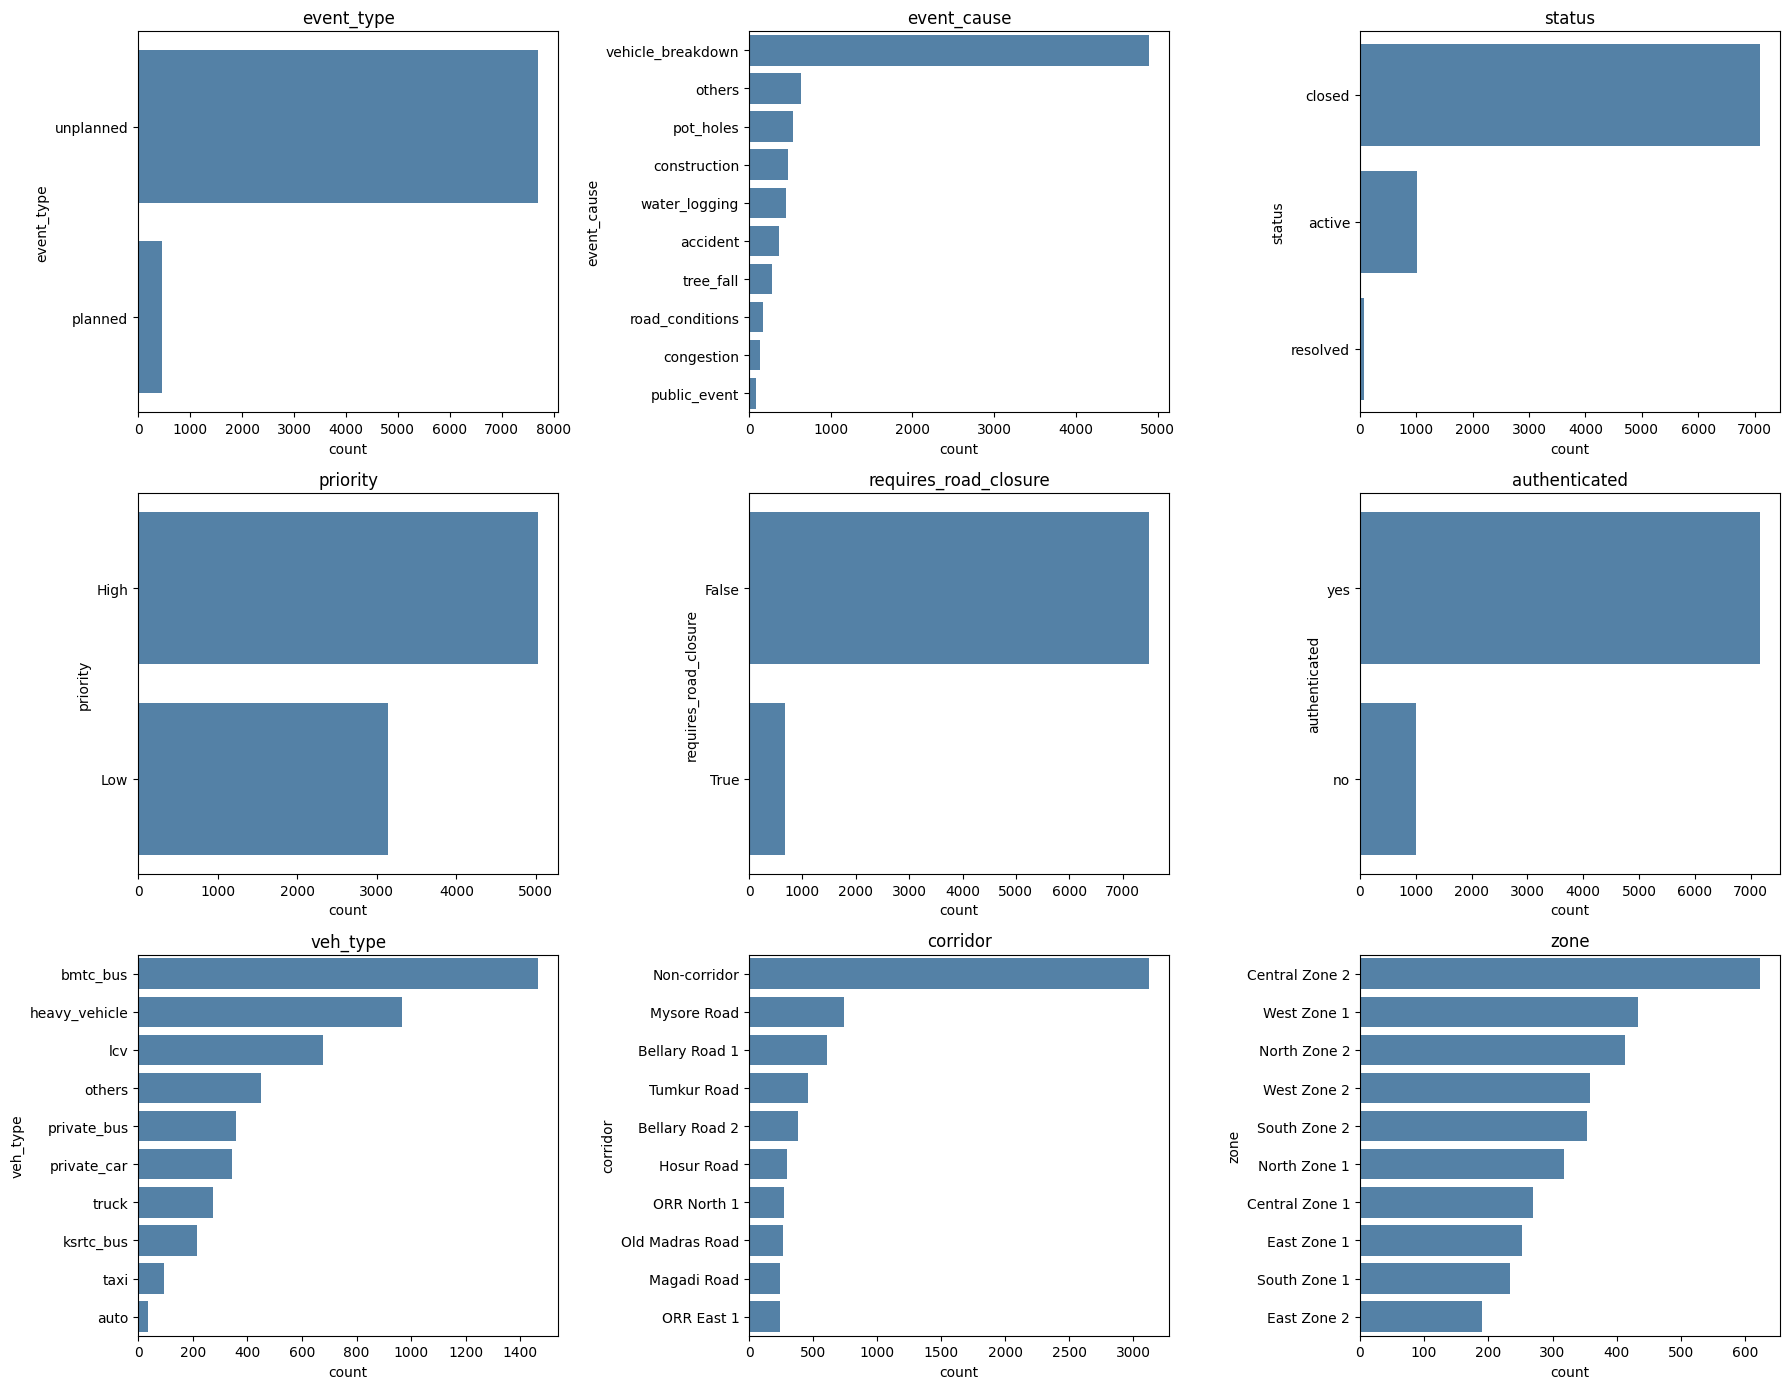

In [17]:
cat_cols = ["event_type", "event_cause", "status", "priority", "requires_road_closure",
            "authenticated", "veh_type", "corridor", "zone"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().head(10).index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

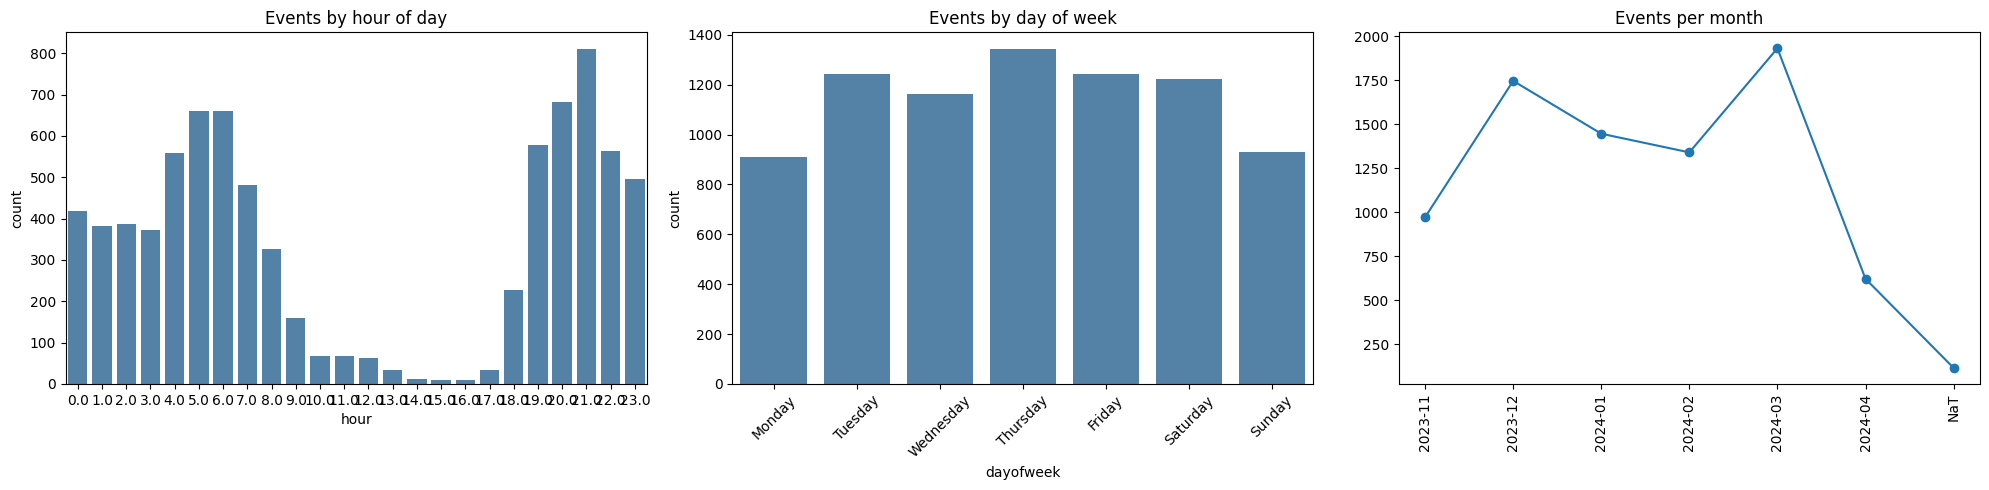

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# by hour
sns.countplot(data=df, x="hour", ax=axes[0], color="steelblue")
axes[0].set_title("Events by hour of day")

# by day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=df, x="dayofweek", order=dow_order, ax=axes[1], color="steelblue")
axes[1].set_title("Events by day of week")
axes[1].tick_params(axis="x", rotation=45)

# by month (trend over time)
month_counts = df["month"].value_counts().sort_index()
axes[2].plot(month_counts.index, month_counts.values, marker="o")
axes[2].set_title("Events per month")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

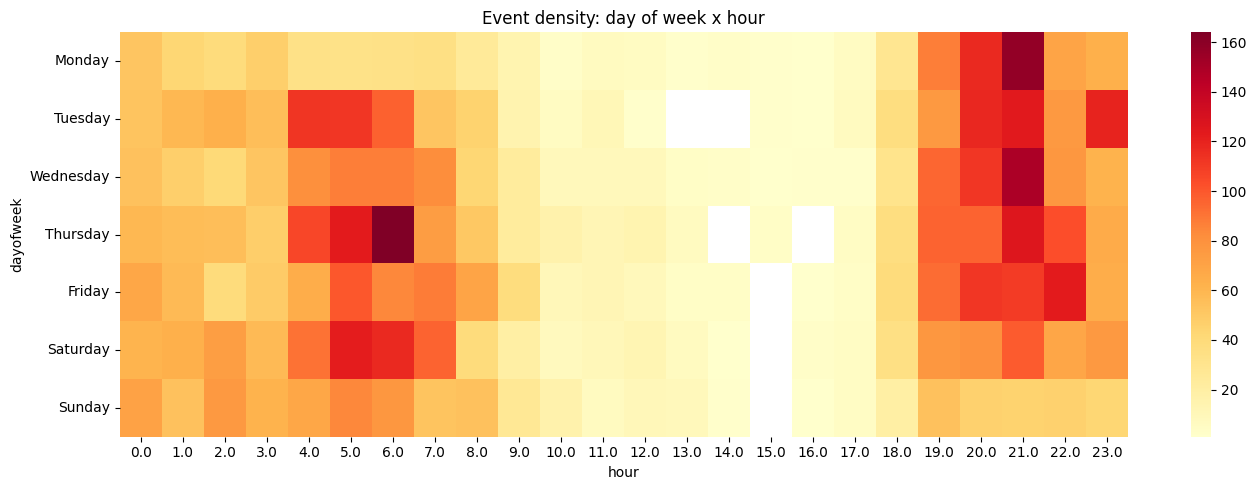

In [19]:
pivot = df.pivot_table(index="dayofweek", columns="hour", values="id", aggfunc="count")
pivot = pivot.reindex(dow_order)
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=False)
plt.title("Event density: day of week x hour")
plt.tight_layout()
plt.show()

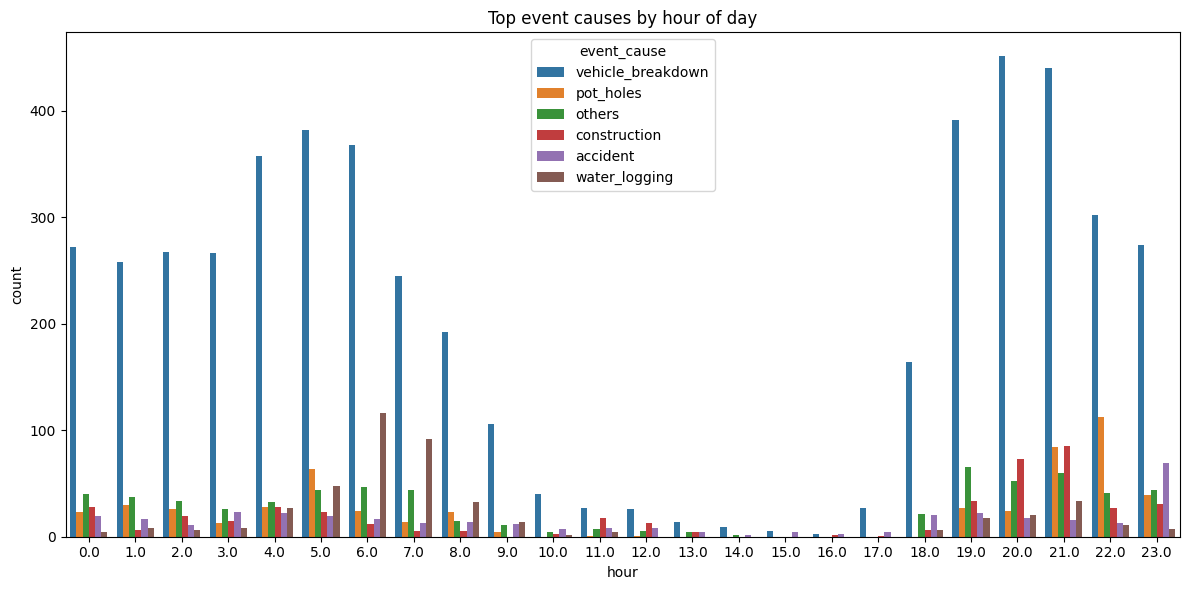

In [20]:
top_causes = df["event_cause"].value_counts().head(6).index
sub = df[df["event_cause"].isin(top_causes)]
plt.figure(figsize=(12, 6))
sns.countplot(data=sub, x="hour", hue="event_cause")
plt.title("Top event causes by hour of day")
plt.tight_layout()
plt.show()

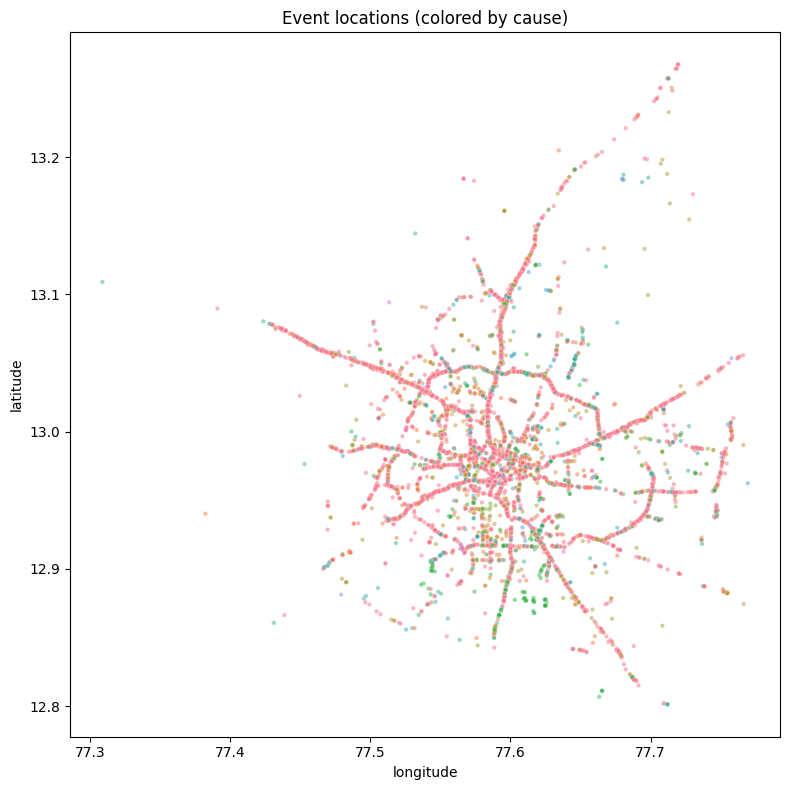

In [21]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="event_cause",
                 s=10, alpha=0.5, legend=False)
plt.title("Event locations (colored by cause)")
plt.tight_layout()
plt.show()


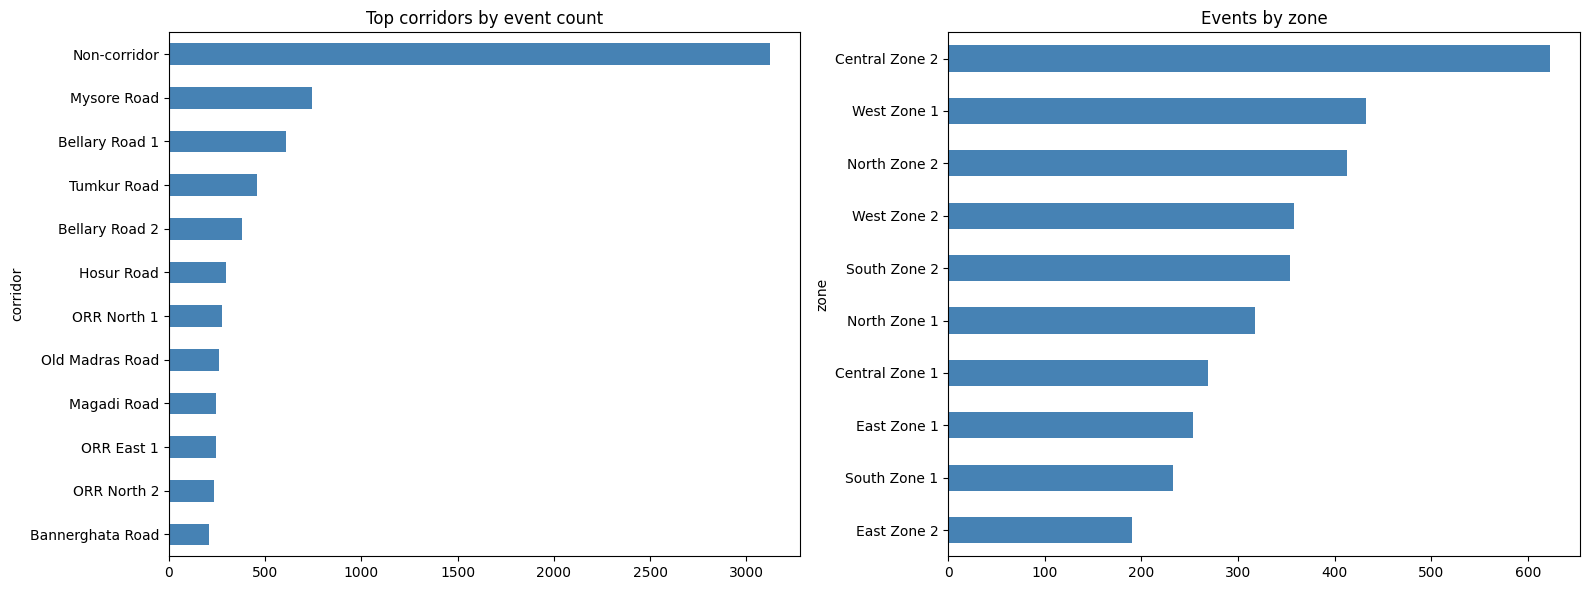

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["corridor"].value_counts().head(12).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top corridors by event count")

df["zone"].value_counts().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].invert_yaxis()
axes[1].set_title("Events by zone")
plt.tight_layout()
plt.show()


Resolution time (minutes) stats:
 count    2460.000000
mean       98.979719
std       206.431908
min         0.696538
25%        22.100364
50%        45.637056
75%        85.249147
max      1437.053099
Name: resolution_min, dtype: float64


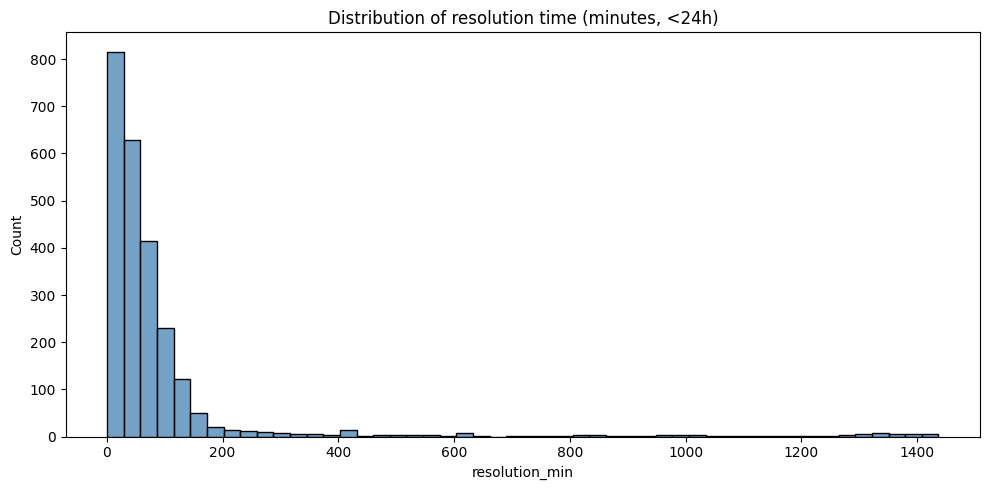

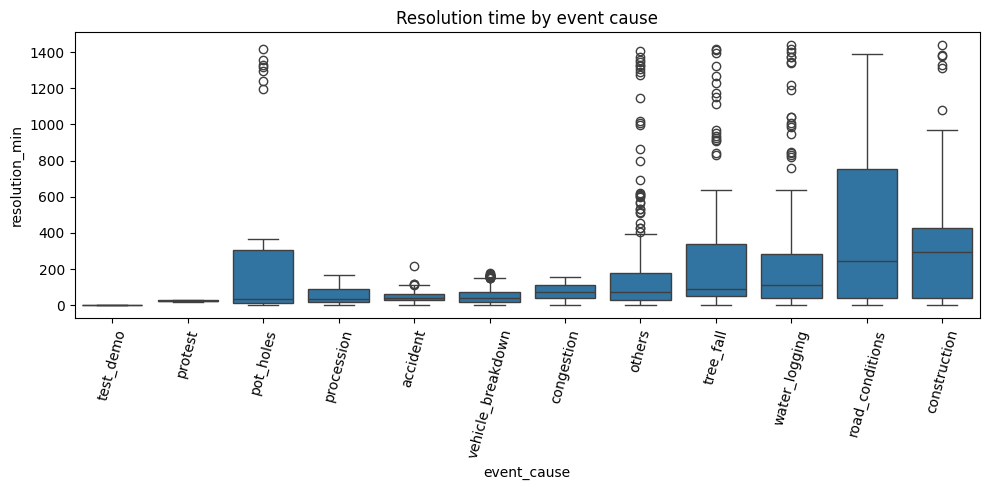

In [23]:
res = df[(df["resolution_min"] > 0) & (df["resolution_min"] < 24 * 60)]  # filter outliers/bad data
print("Resolution time (minutes) stats:\n", res["resolution_min"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(res["resolution_min"], bins=50, color="steelblue")
plt.title("Distribution of resolution time (minutes, <24h)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=res, x="event_cause", y="resolution_min",
            order=res.groupby("event_cause")["resolution_min"].median().sort_values().index)
plt.xticks(rotation=75)
plt.title("Resolution time by event cause")
plt.tight_layout()
plt.show()

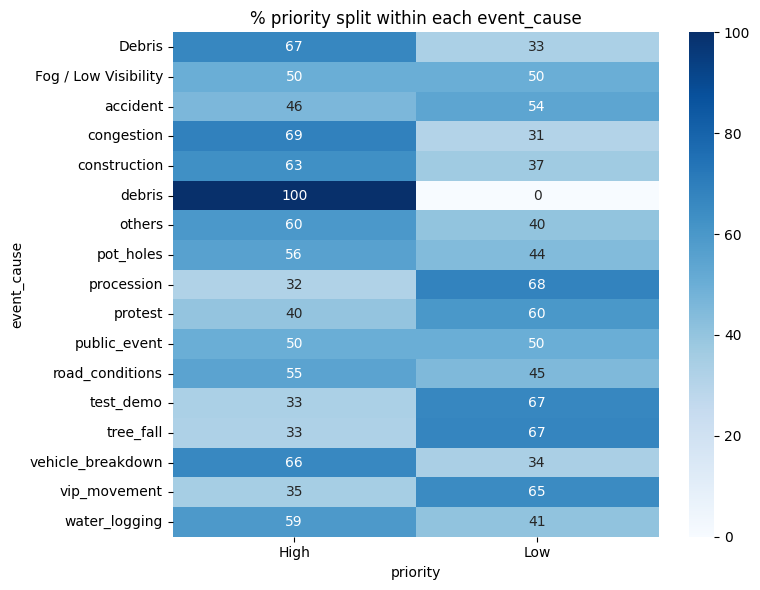

requires_road_closure       False       True 
event_cause                                  
Debris                  91.666667    8.333333
Fog / Low Visibility   100.000000    0.000000
accident                96.986301    3.013699
congestion              95.588235    4.411765
construction            73.541667   26.458333
debris                   0.000000  100.000000
others                  91.379310    8.620690
pot_holes               97.579143    2.420857
procession              73.611111   26.388889
protest                 60.000000   40.000000
public_event            53.571429   46.428571
road_conditions         87.647059   12.352941
test_demo              100.000000    0.000000
tree_fall               60.563380   39.436620
vehicle_breakdown       95.710784    4.289216
vip_movement            20.000000   80.000000
water_logging           91.484716    8.515284


In [24]:
ct = pd.crosstab(df["event_cause"], df["priority"], normalize="index") * 100
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="Blues")
plt.title("% priority split within each event_cause")
plt.tight_layout()
plt.show()

ct2 = pd.crosstab(df["event_cause"], df["requires_road_closure"], normalize="index") * 100
print(ct2)

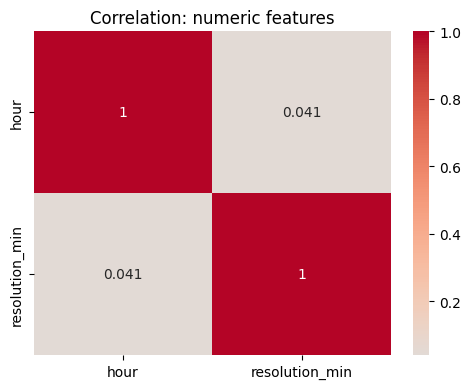


Done. Use the plots above to decide:
- Which low-signal columns (>90% missing) to drop
- Time-based features: hour, dayofweek, is_peak_hour, month/season
- Spatial features: corridor, zone, or geohash binning from lat/long
- Target/label candidates: event_cause, priority, requires_road_closure, resolution_min


In [25]:
num_cols = ["hour", "resolution_min"]
df_num = df[num_cols].dropna()
if len(df_num) > 1:
    plt.figure(figsize=(5, 4))
    sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation: numeric features")
    plt.tight_layout()
    plt.show()

print("\nDone. Use the plots above to decide:")
print("- Which low-signal columns (>90% missing) to drop")
print("- Time-based features: hour, dayofweek, is_peak_hour, month/season")
print("- Spatial features: corridor, zone, or geohash binning from lat/long")
print("- Target/label candidates: event_cause, priority, requires_road_closure, resolution_min")